# Stock High-Gainer Prediction System
## Complete Pipeline — NSE Large-Cap Daily Range Predictor

**Model:** `xgb_dir_wide_bullish` — Predicts next-day high-low range >5% with directional bias.

**Architecture:** 74 features → XGBoost classifier → D9 decile scoring → Discovery engine.

**Universe:** ~90 NSE large-caps | **Timeframe:** 1day | **Period:** 2016–2026

---
**IMPORTANT:** Each code cell below is **fully self-contained** — it imports everything it needs and defines all helper functions inline. You can run them in any order, independently.

---
## Cell 1: Build DuckDB Warehouse from CSV files

Reads OHLCV CSV files from `comprehensive_data/` and `nifty50_full_history/`, loads them into DuckDB `raw_market` table. Run once.

In [1]:
import duckdb, time
from pathlib import Path

BASE = Path(r"C:\Users\pc\Downloads\stock hist data")
DB = BASE / "warehouse" / "market_data.duckdb"

def build_warehouse():
    DB.parent.mkdir(parents=True, exist_ok=True)
    con = duckdb.connect(str(DB))
    con.execute('''CREATE TABLE IF NOT EXISTS raw_market (
        datetime TIMESTAMP WITH TIME ZONE, open DOUBLE, high DOUBLE, low DOUBLE,
        close DOUBLE, volume DOUBLE, symbol VARCHAR, timeframe VARCHAR, source VARCHAR)''')

    def load_batch(src, folder, suffix, tf_label):
        for fpath in sorted(folder.glob(f"*_{suffix}.csv")):
            sym = fpath.stem[:-(len(suffix)+1)]
            if con.execute("SELECT 1 FROM raw_market WHERE symbol=? AND timeframe=? AND source=? LIMIT 1",
                           [sym, tf_label, src]).fetchone(): continue
            con.execute(f"""INSERT INTO raw_market SELECT datetime::TIMESTAMPTZ, open::DOUBLE,
                high::DOUBLE, low::DOUBLE, close::DOUBLE, volume::DOUBLE,
                '{sym}', '{tf_label}', '{src}' FROM read_csv_auto('{fpath}')""")

    FH = BASE / "nifty50_full_history"; CD = BASE / "comprehensive_data"
    if CD.exists():
        for suf, tf in [("ONE_DAY","1day"),("ONE_HOUR","60min"),("FIFTEEN_MINUTE","15min")]:
            load_batch("comprehensive", CD, suf, tf)
    if FH.exists():
        load_batch("full_history", FH, "FIFTEEN_MINUTE", "15min")
    con.execute("CREATE INDEX IF NOT EXISTS idx_sym_tf_dt ON raw_market(symbol,timeframe,datetime)")
    r = con.execute("SELECT COUNT(*),COUNT(DISTINCT symbol) FROM raw_market").fetchone()
    d = con.execute("SELECT MIN(datetime)::DATE,MAX(datetime)::DATE FROM raw_market").fetchone()
    con.close(); print(f"{r[0]:,} rows, {r[1]} symbols, {d[0]} to {d[1]}")

# Run:
# build_warehouse()

---
## Cell 2: Load Delivery Data from NSE

Fetches delivery % via nselib for all symbols in feature_store. Stores in `delivery_data` table. Run after warehouse and feature_pipeline.

In [2]:
import duckdb, pandas as pd
from pathlib import Path
from nselib import capital_market

DB = Path(r"C:\Users\pc\Downloads\stock hist data") / "warehouse" / "market_data.duckdb"

def load_delivery():
    con = duckdb.connect(str(DB))
    syms = [r[0] for r in con.execute(
        "SELECT DISTINCT symbol FROM feature_store WHERE timeframe='1day' ORDER BY symbol").fetchall()]
    con.execute('''CREATE TABLE IF NOT EXISTS delivery_data (
        symbol VARCHAR, date DATE, traded_qty BIGINT, deliverable_qty BIGINT, delivery_pct DOUBLE)''')
    total = 0
    for i, sym in enumerate(syms):
        try:
            df = capital_market.deliverable_position_data(sym, from_date="01-01-2016", to_date="01-06-2026")
            rows = []
            for _, r in df.iterrows():
                try: dt = pd.to_datetime(r["Date"], format="%d-%b-%Y")
                except: continue
                rows.append((sym, dt.date(),
                    int(str(r.get("TradedQty","0")).replace(",","") or "0"),
                    int(str(r.get("DeliverableQty","0")).replace(",","") or "0"),
                    float(str(r.get("%DlyQttoTradedQty","0")).replace(",","") or "0")))
            if rows:
                con.executemany("INSERT INTO delivery_data VALUES (?,?,?,?,?)", rows)
                total += len(rows)
        except: pass
    con.close(); print(f"Delivery: {total} rows, {len(syms)} symbols")

# Run:
# load_delivery()

---
## Cell 3: Technical Indicators (45 features)

All indicator functions + master `compute_all_indicators(df)`. Pass any OHLCV DataFrame to get 45+ technical columns. Self-contained.

In [3]:
import pandas as pd, numpy as np

def _tr(h, l, c):
    return pd.DataFrame({
        "hl": h - l,
        "hc": (h - c.shift()).abs(),
        "lc": (l - c.shift()).abs()
    }).max(axis=1)

def add_sma(df, p=[5, 10, 20, 50, 200]):
    for x in p:
        df[f"sma_{x}"] = df["close"].rolling(x).mean()
    return df

def add_ema(df, p=[5, 10, 20, 50, 200]):
    for x in p:
        df[f"ema_{x}"] = df["close"].ewm(span=x).mean()
    return df

def add_macd(df, f=12, s=26, sg=9):
    ef = df["close"].ewm(span=f).mean()
    es = df["close"].ewm(span=s).mean()
    df["macd_line"] = ef - es
    df["macd_signal"] = df["macd_line"].ewm(span=sg).mean()
    df["macd_hist"] = df["macd_line"] - df["macd_signal"]
    return df

def add_adx(df, p=14):
    t = _tr(df["high"], df["low"], df["close"])
    u = df["high"] - df["high"].shift()
    d = df["low"].shift() - df["low"]
    pdm = np.where((u > d) & (u > 0), u, 0)
    mdm = np.where((d > u) & (d > 0), d, 0)
    a = t.ewm(span=p).mean()
    pdi = 100 * pd.Series(pdm, index=df.index).ewm(span=p).mean() / a
    mdi = 100 * pd.Series(mdm, index=df.index).ewm(span=p).mean() / a
    df["adx"] = 100 * (pdi - mdi).abs() / (pdi + mdi + 1e-10)
    df["plus_di"] = pdi
    df["minus_di"] = mdi
    return df

def add_cci(df, p=20):
    tp = (df["high"] + df["low"] + df["close"]) / 3
    df["cci"] = (tp - tp.rolling(p).mean()) / (
        0.015 * tp.rolling(p).apply(lambda x: abs(x - x.mean()).mean()) + 1e-10
    )
    return df

def add_rsi(df, p=[7, 14, 21]):
    d = df["close"].diff()
    g = d.clip(lower=0)
    l = (-d).clip(lower=0)
    for x in p:
        ag = g.ewm(span=x).mean()
        al = l.ewm(span=x).mean()
        df[f"rsi_{x}"] = 100 - 100 / (1 + ag / (al + 1e-10))
    return df

def add_stoch(df, k=5, d=3):
    lk = df["low"].rolling(k).min()
    hk = df["high"].rolling(k).max()
    k_val = 100 * (df["close"] - lk) / (hk - lk + 1e-10)
    df["stoch_k"] = k_val
    df["stoch_d"] = k_val.rolling(d).mean()
    return df

def add_williams_r(df, p=14):
    hp = df["high"].rolling(p).max()
    lp = df["low"].rolling(p).min()
    df["williams_r"] = -100 * (hp - df["close"]) / (hp - lp + 1e-10)
    return df

def add_roc(df, p=[5, 10, 20]):
    for x in p:
        df[f"roc_{x}"] = df["close"].pct_change(x) * 100
    return df

def add_trix(df, p=15):
    e1 = df["close"].ewm(span=p).mean()
    e2 = e1.ewm(span=p).mean()
    e3 = e2.ewm(span=p).mean()
    df["trix"] = e3.pct_change() * 100
    return df

def add_mfi(df, p=14):
    tp = (df["high"] + df["low"] + df["close"]) / 3
    flow = (tp * df["volume"]).where(tp > tp.shift(), -tp * df["volume"])
    df["mfi"] = 100 - 100 / (
        1 + flow.where(flow > 0, 0).rolling(p).sum() /
        (-flow.where(flow < 0, 0)).rolling(p).sum() + 1e-10
    )
    return df

def add_uo(df, p1=7, p2=14, p3=28):
    bp = df["close"] - np.minimum(df["low"], df["close"].shift())
    t = _tr(df["high"], df["low"], df["close"])
    a1 = bp.rolling(p1).sum() / (t.rolling(p1).sum() + 1e-10)
    a2 = bp.rolling(p2).sum() / (t.rolling(p2).sum() + 1e-10)
    a3 = bp.rolling(p3).sum() / (t.rolling(p3).sum() + 1e-10)
    df["uo"] = 100 * (4 * a1 + 2 * a2 + a3) / 7
    return df

def add_atr(df, p=[7, 14, 21]):
    t = _tr(df["high"], df["low"], df["close"])
    for x in p:
        df[f"atr_{x}"] = t.ewm(span=x).mean()
    return df

def add_bollinger(df, p=20, std=2):
    s = df["close"].rolling(p).mean()
    s2 = df["close"].rolling(p).std()
    df["bb_pct_b"] = (df["close"] - s + std * s2) / (2 * std * s2 + 1e-10)
    df["bb_width"] = 2 * std * s2 / s * 100
    return df

def add_keltner(df, p=20, am=1.5):
    e = df["close"].ewm(span=p).mean()
    a = _tr(df["high"], df["low"], df["close"]).ewm(span=p).mean()
    df["kc_width"] = 2 * am * a / e * 100
    return df

def add_donchian(df, p=20):
    du = df["high"].rolling(p).max()
    dl = df["low"].rolling(p).min()
    df["dc_width"] = (du - dl) / ((du + dl) / 2) * 100
    return df

def add_hv(df, p=[10, 20, 30]):
    lr = np.log(df["close"] / df["close"].shift())
    for x in p:
        df[f"hv_{x}"] = lr.rolling(x).std() * np.sqrt(x) * 100
    return df

def add_obv(df):
    df["obv"] = (np.sign(df["close"].diff()).fillna(0) * df["volume"]).cumsum()
    return df

def add_cmf(df, p=20):
    mf = ((df["close"] - df["low"]) - (df["high"] - df["close"])) / (
        df["high"] - df["low"] + 1e-10
    ) * df["volume"]
    df["cmf"] = mf.rolling(p).sum() / (df["volume"].rolling(p).sum() + 1e-10)
    return df

def add_vpt(df):
    df["vpt"] = (df["volume"] * df["close"].pct_change()).fillna(0).cumsum()
    return df

def add_ad_line(df):
    mf = ((df["close"] - df["low"]) - (df["high"] - df["close"])) / (
        df["high"] - df["low"] + 1e-10
    )
    df["ad_line"] = (mf * df["volume"]).cumsum()
    return df

def add_eom(df, p=14):
    d = (df["high"] + df["low"]) / 2 - (df["high"].shift() + df["low"].shift()) / 2
    br = (df["volume"] / 1e6) / (df["high"] - df["low"] + 1e-10)
    df["eom"] = (d / br).rolling(p).mean()
    return df

def add_fi(df, p=13):
    df["fi"] = (df["close"].diff() * df["volume"]).ewm(span=p).mean()
    return df

def add_zscore(df, p=20):
    df[f"zscore_{p}"] = (df["close"] - df["close"].rolling(p).mean()) / (
        df["close"].rolling(p).std() + 1e-10
    )
    return df

def add_skew(df, p=20):
    df[f"skew_{p}"] = df["close"].rolling(p).skew()
    return df

def add_kurt(df, p=20):
    df[f"kurt_{p}"] = df["close"].rolling(p).kurt()
    return df

FUNCS = [
    add_sma, add_ema, add_macd, add_adx, add_cci, add_rsi, add_stoch,
    add_williams_r, add_roc, add_trix, add_mfi, add_uo, add_atr,
    add_bollinger, add_keltner, add_donchian, add_hv, add_obv,
    add_cmf, add_vpt, add_ad_line, add_eom, add_fi, add_zscore,
    add_skew, add_kurt
]

def compute_all_indicators(df):
    for fn in FUNCS:
        try:
            df = fn(df)
        except Exception:
            pass
    return df

---
## Cell 4: Feature Lists — All 74 Feature Names

Defines BASE_F (45), CAL_F (5), VIX_F (9), DV_F (4), MTF_F (10), RNG_F (1) and ALL_F (74). Used by all downstream cells. Self-contained.

In [ ]:
BASE_F = ["sma_5","sma_10","sma_20","sma_50","ema_5","ema_10","ema_20","ema_50",
          "rsi_7","rsi_14","rsi_21","macd_line","macd_signal","macd_hist","adx",
          "plus_di","minus_di","atr_7","atr_14","atr_21","bb_pct_b","bb_width",
          "kc_width","dc_width","obv","cmf","stoch_k","stoch_d","williams_r",
          "mfi","uo","cci","trix","roc_5","roc_10","roc_20","zscore_20",
          "skew_20","kurt_20","hv_10","hv_20","hv_30","eom","fi","vpt"]
CAL_F = ["dow","month","is_month_end","is_quarter_end","is_thursday"]
VIX_F = ["vix_close","vix_change","vix_range","vix_ma_5","vix_ma_20",
         "vix_zscore_20","vix_ma_5_r","vix_ma_20_r","vix_high_r"]
DV_F = ["delivery_pct","delivery_pct_ma5","delivery_pct_ma20","delivery_delta"]
MTF_F = ["intra_rsi_mean","intra_rsi_std","intra_vol_std","intra_range_sum",
         "intra_range_max","intra_bb_width_mean","intra_macd_std",
         "intra_rsi_mean_ma5","intra_range_sum_ma5","intra_vol_std_ma5"]
RNG_F = ["range_pct"]
ALL_F = BASE_F + RNG_F + CAL_F + VIX_F + DV_F + MTF_F
print(f"{len(ALL_F)} features: {len(BASE_F)} base + {len(CAL_F)} cal + {len(VIX_F)} vix + {len(DV_F)} delivery + {len(MTF_F)} intraday + {len(RNG_F)} range")

74 features: 45 base + 5 cal + 9 vix + 4 delivery + 10 intraday + 1 range


---
## Cell 5: Load Full Feature Data from DB

Loads all 74 features + forward returns + targets from DuckDB. Returns DataFrame ready for model training. Run after warehouse + feature_pipeline. Requires ALL_F from Cell 4.

In [8]:
import duckdb, pandas as pd, numpy as np
from pathlib import Path

DB = Path(r"C:\Users\pc\Downloads\stock hist data") / "warehouse" / "market_data.duckdb"

# Paste ALL_F from Cell 4 (or run Cell 4 first)
BASE_F = ["sma_5","sma_10","sma_20","sma_50","ema_5","ema_10","ema_20","ema_50",
          "rsi_7","rsi_14","rsi_21","macd_line","macd_signal","macd_hist","adx",
          "plus_di","minus_di","atr_7","atr_14","atr_21","bb_pct_b","bb_width",
          "kc_width","dc_width","obv","cmf","stoch_k","stoch_d","williams_r",
          "mfi","uo","cci","trix","roc_5","roc_10","roc_20","zscore_20",
          "skew_20","kurt_20","hv_10","hv_20","hv_30","eom","fi","vpt"]
CAL_F = ["dow","month","is_month_end","is_quarter_end","is_thursday"]
VIX_F = ["vix_close","vix_change","vix_range","vix_ma_5","vix_ma_20",
         "vix_zscore_20","vix_ma_5_r","vix_ma_20_r","vix_high_r"]
DV_F = ["delivery_pct","delivery_pct_ma5","delivery_pct_ma20","delivery_delta"]
MTF_F = ["intra_rsi_mean","intra_rsi_std","intra_vol_std","intra_range_sum",
         "intra_range_max","intra_bb_width_mean","intra_macd_std",
         "intra_rsi_mean_ma5","intra_range_sum_ma5","intra_vol_std_ma5"]
RNG_F = ["range_pct"]
ALL_F = BASE_F + RNG_F + CAL_F + VIX_F + DV_F + MTF_F

def load_feature_data():
    con = duckdb.connect(str(DB))

    # Base features from feature_store (1day)
    df = con.execute(f"SELECT symbol,datetime,"+",".join(BASE_F)+
        ",high,low,close,(high-low)/close*100 as range_pct FROM feature_store "
        "WHERE timeframe='1day' ORDER BY datetime").fetchdf()

    # Normalize datetime (strip tz, convert to us)
    ds = pd.to_datetime(df["datetime"])
    if hasattr(ds.dt,"tz") and ds.dt.tz is not None:
        df["datetime"] = ds.dt.tz_convert("UTC").dt.tz_localize(None).astype("datetime64[us]")
    else: df["datetime"] = ds.astype("datetime64[us]")

    df["year"] = pd.to_datetime(df["datetime"]).dt.year
    df = df.sort_values("datetime")
    dt = pd.to_datetime(df["datetime"])
    df["dow"] = dt.dt.dayofweek; df["month"] = dt.dt.month
    df["is_month_end"] = dt.dt.is_month_end.astype(int)
    df["is_quarter_end"] = dt.dt.is_quarter_end.astype(int)
    df["is_thursday"] = (df["dow"] == 3).astype(int)

    # VIX
    v = con.execute("SELECT datetime,vix_close,vix_change,vix_range,vix_ma_5,"
        "vix_ma_20,vix_zscore_20 FROM vix_data ORDER BY datetime").fetchdf()
    vd = pd.to_datetime(v["datetime"])
    if hasattr(vd.dt,"tz") and vd.dt.tz is not None:
        v["datetime"] = vd.dt.tz_convert("UTC").dt.tz_localize(None).astype("datetime64[us]")
    else: v["datetime"] = vd.astype("datetime64[us]")
    v["vix_ma_5_r"] = v["vix_close"]/v["vix_ma_5"].replace(0,np.nan)-1
    v["vix_ma_20_r"] = v["vix_close"]/v["vix_ma_20"].replace(0,np.nan)-1
    v["vix_high_r"] = 0.0; v = v.fillna(0)
    df = pd.merge_asof(df.sort_values("datetime"), v.sort_values("datetime"),
                       on="datetime", direction="backward")

    # Delivery
    dv = con.execute("SELECT symbol,date,delivery_pct FROM delivery_data "
        "ORDER BY symbol,date").fetchdf()
    dv["date"] = pd.to_datetime(dv["date"]).astype("datetime64[us]")
    dv["delivery_pct_ma5"] = dv.groupby("symbol")["delivery_pct"].transform(
        lambda x: x.rolling(5,min_periods=2).mean())
    dv["delivery_pct_ma20"] = dv.groupby("symbol")["delivery_pct"].transform(
        lambda x: x.rolling(20,min_periods=5).mean())
    dv["delivery_delta"] = dv["delivery_pct"] - dv["delivery_pct_ma5"]
    dv = dv.fillna(0)
    df["date_m"] = pd.to_datetime(df["datetime"]).dt.normalize()
    df = df.merge(dv, left_on=["symbol","date_m"], right_on=["symbol","date"], how="left")
    for c in DV_F: df[c] = df[c].fillna(0)

    # Intraday (60min)
    m = con.execute("SELECT symbol,datetime,high,low,close,rsi_14,bb_width,macd_hist "
        "FROM feature_store WHERE timeframe='60min' ORDER BY datetime").fetchdf()
    md = pd.to_datetime(m["datetime"])
    if hasattr(md.dt,"tz") and md.dt.tz is not None:
        m["datetime"] = md.dt.tz_convert("UTC").dt.tz_localize(None).astype("datetime64[us]")
    else: m["datetime"] = md.astype("datetime64[us]")
    m["date"] = pd.to_datetime(m["datetime"]).dt.normalize()
    m["r"] = (m["high"]-m["low"])/m["close"]*100
    mtf = m.groupby(["symbol","date"]).agg(
        intra_rsi_mean=("rsi_14","mean"), intra_rsi_std=("rsi_14","std"),
        intra_vol_std=("close",lambda x: float(np.std(np.diff(x.values))/np.mean(x)*100) if len(x)>1 else 0),
        intra_range_sum=("r","sum"), intra_range_max=("r","max"),
        intra_bb_width_mean=("bb_width","mean"), intra_macd_std=("macd_hist","std")
    ).reset_index()
    for c in ["intra_rsi_mean","intra_range_sum","intra_vol_std"]:
        mtf[f"{c}_ma5"] = mtf.groupby("symbol")[c].transform(
            lambda x: x.rolling(5,min_periods=2).mean())
    df = df.merge(mtf, left_on=["symbol","date_m"], right_on=["symbol","date"], how="left")
    for c in MTF_F: df[c] = df[c].fillna(0)
    con.close()

    # Forward targets
    ng = df.groupby("symbol")
    df["fwd_return_1d"] = (ng["close"].shift(-1) / df["close"] - 1) * 100
    df["range_next"] = (ng["high"].shift(-1) - ng["low"].shift(-1)) / df["close"] * 100
    df["label_5pct"] = ((df["range_next"] > 5) & (df["fwd_return_1d"] > 0)).astype(int)
    df["label_2pct"] = ((df["range_next"] > 2) & (df["fwd_return_1d"] > 0)).astype(int)
    df["label_3pct"] = ((df["range_next"] > 3) & (df["fwd_return_1d"] > 0)).astype(int)

    return df.dropna(subset=ALL_F)

# Run:
df = load_feature_data()
print(f"{len(df)} rows, {df['symbol'].nunique()} symbols")
print(f"Base rate 5%: {df['label_5pct'].mean():.2%}, 2%: {df['label_2pct'].mean():.2%}, 3%: {df['label_3pct'].mean():.2%}")

226231 rows, 90 symbols
Base rate 5%: 5.76%, 2%: 30.54%, 3%: 17.79%


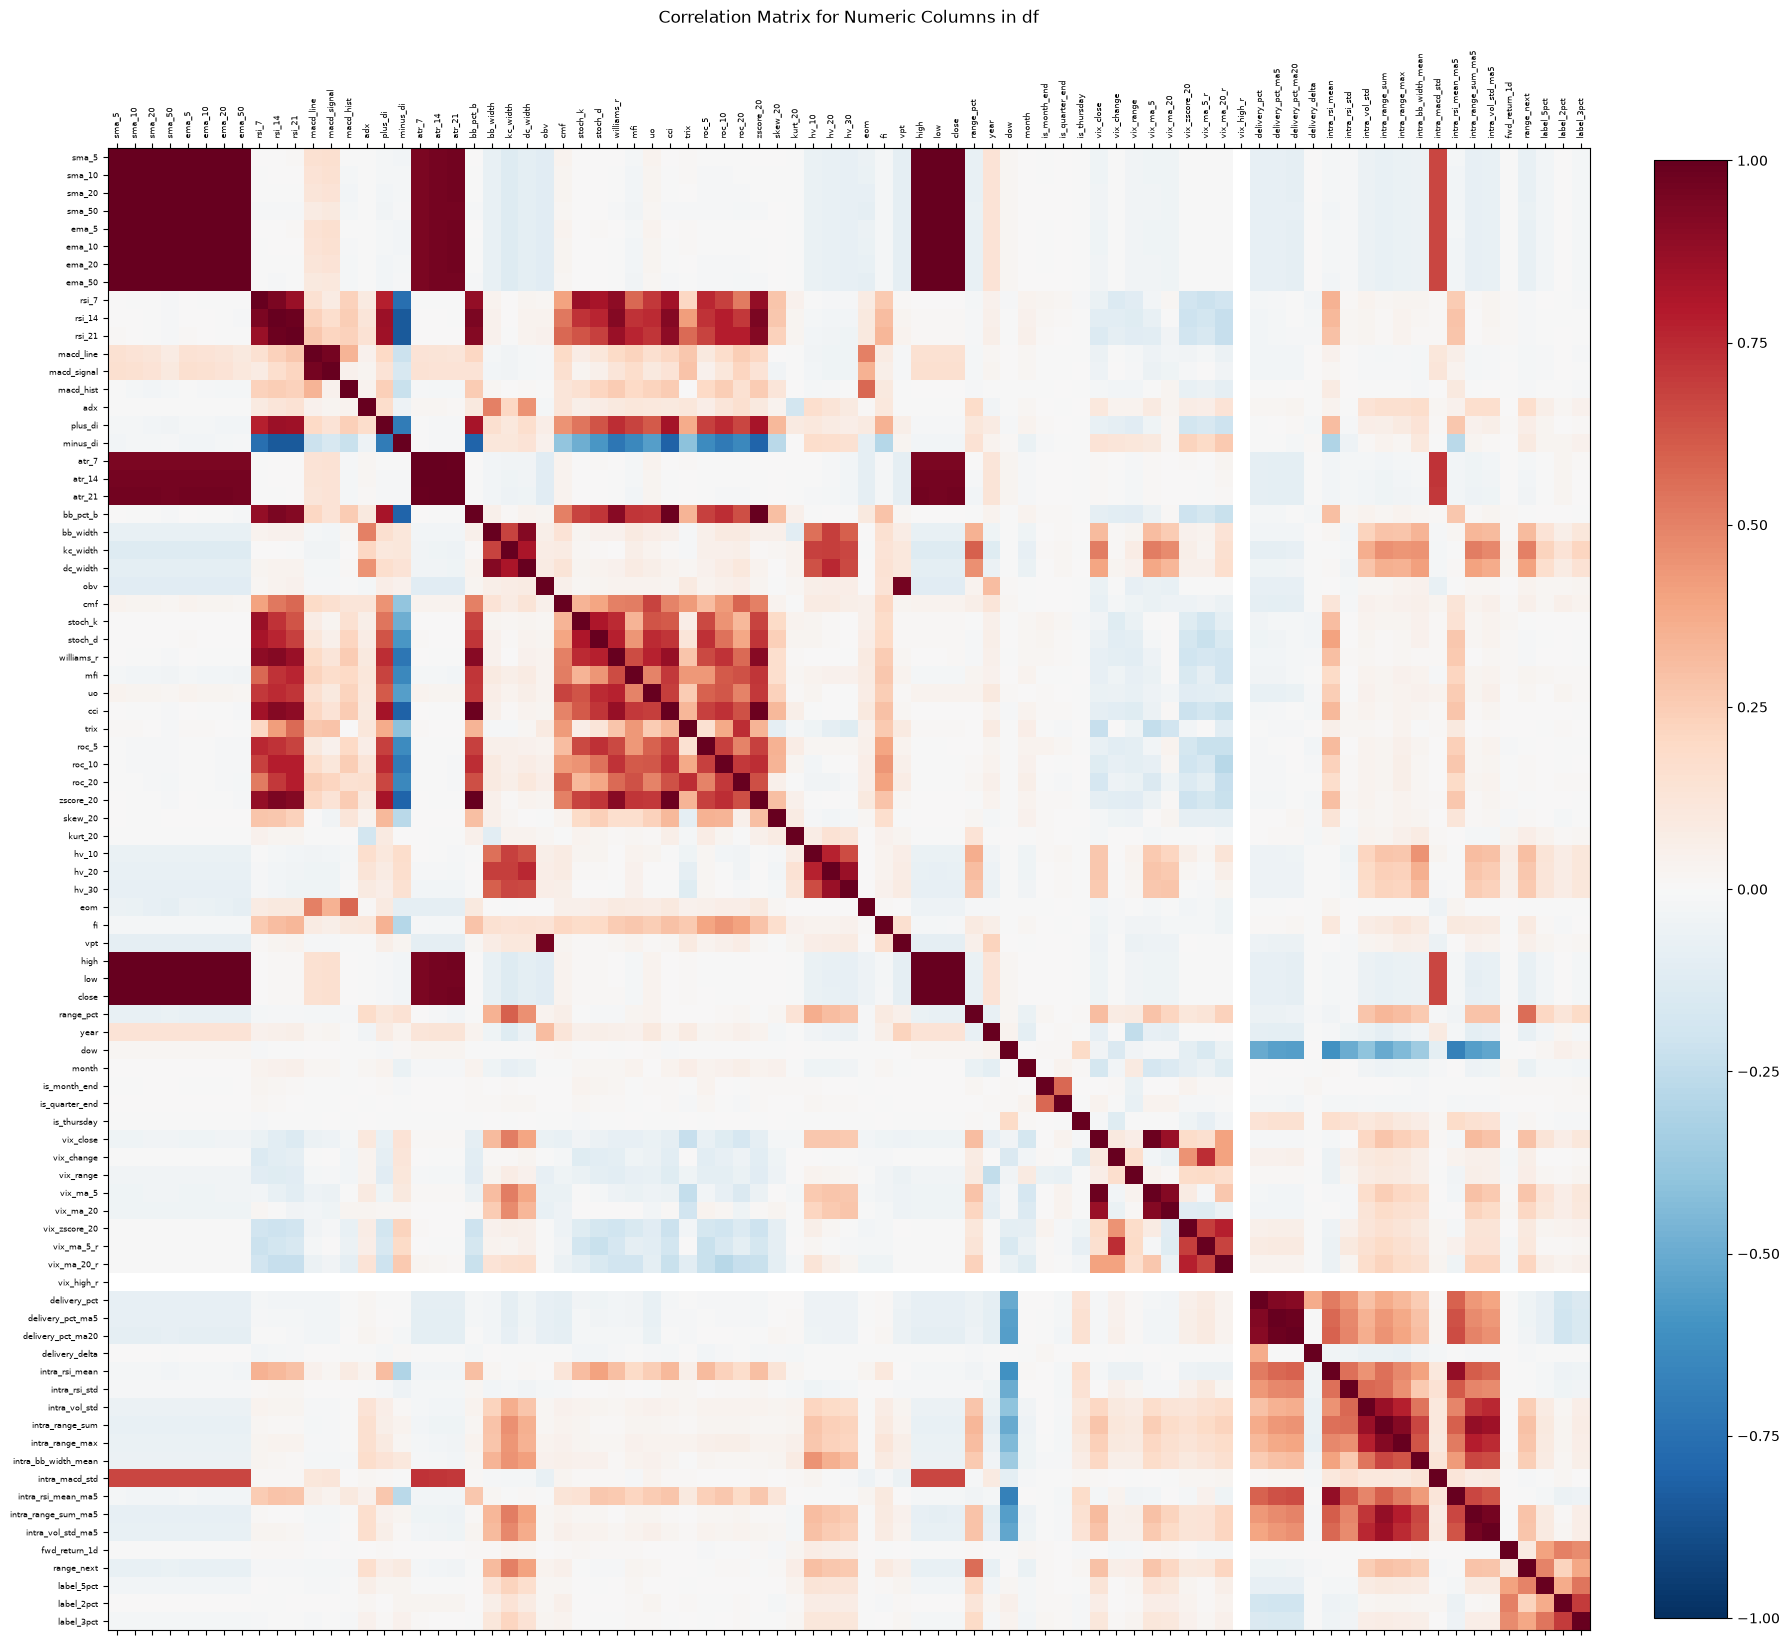

In [12]:
import matplotlib.pyplot as plt

num = df.select_dtypes(include=["number"])
corr = num.corr()

fig, ax = plt.subplots(figsize=(18, 18))
cax = ax.matshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
fig.colorbar(cax, fraction=0.045, pad=0.04)

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_yticklabels(labels, fontsize=6)

ax.set_title("Correlation Matrix for Numeric Columns in df", pad=20)
plt.tight_layout()
plt.show()

In [19]:
df[["fwd_return_1d","range_next","label_5pct","label_2pct","label_3pct"]].head(100)

,fwd_return_1d,range_next,label_5pct,label_2pct,label_3pct
3909,-1.152727,2.604029,0,0,0
3910,-0.440499,1.341673,0,0,0
3911,-0.429646,3.580380,0,0,0
3912,-0.212072,3.327896,0,0,0
3913,0.390295,2.774262,0,1,0
...,...,...,...,...,...
4006,-0.179949,1.542416,0,0,0
4007,1.857513,3.279899,0,1,1
4008,-0.128297,2.186386,0,0,0
4010,-0.948055,1.777602,0,0,0


In [16]:
# List features correlated with the chosen label in descending order
# Requires existing 'pairs' DataFrame and 'target' variable in notebook namespace.

if 'pairs' not in globals():
    raise RuntimeError("pairs DataFrame not found in the notebook namespace")
if 'target' not in globals():
    raise RuntimeError("target variable (label name) not found")

res = pairs[pairs['target'] == target].sort_values('corr', ascending=False).reset_index(drop=True)
print(f"Correlated features with {target} (descending):")
print(res[['feature', 'corr']].to_string(index=False))

Correlated features with label_5pct (descending):
            feature      corr
           kc_width  0.221887
          range_pct  0.208762
           dc_width  0.171804
           bb_width  0.135359
           vix_ma_5  0.132848
          vix_close  0.131940
              hv_10  0.128739
              hv_20  0.122961
              hv_30  0.117414
          vix_ma_20  0.114514
    intra_range_sum  0.094741
intra_range_sum_ma5  0.090301
    intra_range_max  0.089232
  intra_vol_std_ma5  0.087669
intra_bb_width_mean  0.080460
      intra_vol_std  0.079685
                adx  0.057373
        vix_ma_20_r  0.056816
            kurt_20  0.032014
           minus_di  0.031041
      vix_zscore_20  0.030949
            plus_di  0.024120
                vpt  0.023531
          vix_range  0.023289
                cmf  0.021104
                dow  0.019569
                obv  0.016218
                mfi  0.016046
                 fi  0.013229
       is_month_end  0.012229
         vix_ma_5_r 

,feature_1,feature_2,corr
1696,bb_pct_b,zscore_20,1.000000
4,sma_5,ema_5,0.999985
88,sma_10,ema_10,0.999971
172,sma_20,ema_20,0.999946
3782,high,close,0.999932
...,...,...,...
690,rsi_7,stoch_k,0.863850
674,rsi_7,rsi_21,0.861177
3361,hv_20,hv_30,0.859385
762,rsi_14,plus_di,0.857222


---
## Cell 6: Market Structure Functions

Wyckoff phases, Fair Value Gaps, Order Blocks, Break of Structure, Relative Strength. Self-contained.

In [ ]:
import pandas as pd, numpy as np

def add_fvg(df):
    df["fvg_bullish"] = (df["high"].shift(1) < df["low"]) & (df["volume"] > 0)
    df["fvg_bearish"] = (df["low"].shift(1) > df["high"]) & (df["volume"] > 0)
    return df

def add_order_blocks(df, lb=5):
    df["ob_bullish"] = (df["close"].shift(lb) < df["open"].shift(lb)) & (df["close"] > df["high"].shift(lb))
    df["ob_bearish"] = (df["close"].shift(lb) > df["open"].shift(lb)) & (df["close"] < df["low"].shift(lb))
    return df

def add_bos(df, lb=10):
    ph = df["high"].rolling(lb).max().shift(); pl = df["low"].rolling(lb).min().shift()
    df["bos_up"] = (df["close"] > ph) & (ph > 0)
    df["bos_down"] = (df["close"] < pl) & (pl > 0)
    return df

def add_wyckoff(df, lb=30):
    lp = (df["close"]-df["close"].rolling(lb).min())/(df["close"].rolling(lb).max()-df["close"].rolling(lb).min()+1e-10)
    av = df["volume"].rolling(lb).mean()
    acc = (lp < 0.3) & (df["volume"] > av*1.2); dis = (lp > 0.7) & (df["volume"] > av*1.2)
    ma50 = df["close"].rolling(50, min_periods=20).mean()
    markup = (df["close"] > ma50) & (df["close"] > df["close"].shift(5)) & (df["volume"] > av)
    markdown = (df["close"] < ma50) & (df["close"] < df["close"].shift(5)) & (df["volume"] > av)
    df["wyckoff_phase"] = np.where(acc, 0, np.where(markup, 1, np.where(dis, 2, np.where(markdown, -1, np.nan))))
    return df

def add_rs(df, market_close=None):
    dr = df["close"].pct_change()
    if market_close is not None:
        df["rs_vs_market"] = dr - pd.Series(market_close).pct_change()
        df["rs_ratio_market"] = df["close"] / pd.Series(market_close)
    return df

print("Market structure functions ready: add_fvg, add_order_blocks, add_bos, add_wyckoff, add_rs")

Market structure functions ready: add_fvg, add_order_blocks, add_bos, add_wyckoff, add_rs


---
## Cell 7: XGBoost Model Definition

Classifier + Regressor training functions with StandardScaler. Self-contained.

In [ ]:
import numpy as np, xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

PARAMS = {"n_estimators":120,"max_depth":6,"learning_rate":0.05,
          "subsample":0.8,"colsample_bytree":0.8,"random_state":42,"n_jobs":1,"verbosity":0}

def train_clf(X_tr, y_tr, X_te, y_te):
    clf = xgb.XGBClassifier(**PARAMS, scale_pos_weight=(y_tr==0).sum()/(y_tr==1).sum())
    clf.fit(X_tr, y_tr)
    pred = clf.predict_proba(X_te)[:,1]
    auc = roc_auc_score(y_te, pred)
    return clf, pred, auc

def train_reg(X_tr, y_tr, X_te, y_te):
    reg = xgb.XGBRegressor(n_estimators=80, max_depth=5, learning_rate=0.1,
                           subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=1, verbosity=0)
    reg.fit(X_tr, y_tr)
    pred = reg.predict(X_te)
    mae = np.mean(np.abs(pred - y_te))
    corr = float(np.corrcoef(pred, y_te)[0,1]) if len(pred)>2 else 0
    return reg, pred, mae, corr

print("train_clf and train_reg ready")

train_clf and train_reg ready


---
## Cell 8: Walkforward 5% Model (Production)

Trains `xgb_dir_wide_bullish` with 7 expanding annual windows. Requires ALL_F, load_feature_data, train_clf from cells above.

In [ ]:
import duckdb, pandas as pd, numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import roc_auc_score

DB = Path(r"C:\Users\pc\Downloads\stock hist data") / "warehouse" / "market_data.duckdb"

# Paste ALL_F from Cell 4 if not already defined
if 'ALL_F' not in dir():
    BASE_F = ["sma_5","sma_10","sma_20","sma_50","ema_5","ema_10","ema_20","ema_50",
              "rsi_7","rsi_14","rsi_21","macd_line","macd_signal","macd_hist","adx",
              "plus_di","minus_di","atr_7","atr_14","atr_21","bb_pct_b","bb_width",
              "kc_width","dc_width","obv","cmf","stoch_k","stoch_d","williams_r",
              "mfi","uo","cci","trix","roc_5","roc_10","roc_20","zscore_20",
              "skew_20","kurt_20","hv_10","hv_20","hv_30","eom","fi","vpt"]
    CAL_F = ["dow","month","is_month_end","is_quarter_end","is_thursday"]
    VIX_F = ["vix_close","vix_change","vix_range","vix_ma_5","vix_ma_20",
             "vix_zscore_20","vix_ma_5_r","vix_ma_20_r","vix_high_r"]
    DV_F = ["delivery_pct","delivery_pct_ma5","delivery_pct_ma20","delivery_delta"]
    MTF_F = ["intra_rsi_mean","intra_rsi_std","intra_vol_std","intra_range_sum",
             "intra_range_max","intra_bb_width_mean","intra_macd_std",
             "intra_rsi_mean_ma5","intra_range_sum_ma5","intra_vol_std_ma5"]
    RNG_F = ["range_pct"]
    ALL_F = BASE_F + RNG_F + CAL_F + VIX_F + DV_F + MTF_F

def run_walkforward_5pct(df):
    years = sorted(df["year"].unique())
    windows = [(years[:i], years[i]) for i in range(4, len(years))]
    print(f"Windows: {len(windows)}, Years: {years[0]}-{years[-1]}")
    print(f"Rows: {len(df)}, Base rate: {df['label_5pct'].mean():.2%}")

    con = duckdb.connect(str(DB))
    con.execute('''CREATE TABLE IF NOT EXISTS ml_predictions_oos (
        timeframe VARCHAR, model_name VARCHAR, symbol VARCHAR,
        datetime TIMESTAMP WITH TIME ZONE, score DOUBLE, expected_return DOUBLE)''')

    all_preds = []
    for wi, (ty, test_yr) in enumerate(windows):
        train = df[df["year"].isin(ty)]; test = df[df["year"] == test_yr]
        if len(test) < 50: continue
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(train[ALL_F].values)
        X_te = scaler.transform(test[ALL_F].values)
        clf = xgb.XGBClassifier(n_estimators=120, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=1, verbosity=0,
            scale_pos_weight=(train["label_5pct"]==0).sum()/(train["label_5pct"]==1).sum())
        clf.fit(X_tr, train["label_5pct"].values)
        pred = clf.predict_proba(X_te)[:,1]
        auc = roc_auc_score(test["label_5pct"].values, pred)
        tc = test.copy(); tc["score"] = pred
        tc["d"] = (tc["score"].rank(pct=True)*10).astype(int).clip(0,9)
        d9h = tc[tc["d"]==9]["label_5pct"].mean() if len(tc[tc["d"]==9])>0 else 0
        print(f"  [{wi+1}/{len(windows)}] Test {test_yr}: AUC={auc:.4f} D9Hit={d9h:.1%}")
        for idx, (_, r) in enumerate(test.iterrows()):
            all_preds.append(("1day","xgb_dir_wide_bullish",r["symbol"],r["datetime"],float(pred[idx]),0.0))

    con.execute("DELETE FROM ml_predictions_oos WHERE model_name='xgb_dir_wide_bullish'")
    con.executemany("INSERT INTO ml_predictions_oos VALUES (?,?,?,?,?,?)", all_preds)
    con.close()
    print(f"Stored {len(all_preds)} OOS predictions")
    return all_preds

# Run (after load_feature_data):
# all_preds = run_walkforward_5pct(df)

---
## Cell 9: Walkforward 2% Model

Same as 5% but uses `label_2pct` target. Self-contained code.

In [ ]:
import duckdb, pandas as pd, numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import roc_auc_score

DB = Path(r"C:\Users\pc\Downloads\stock hist data") / "warehouse" / "market_data.duckdb"

if 'ALL_F' not in dir():
    BASE_F = ["sma_5","sma_10","sma_20","sma_50","ema_5","ema_10","ema_20","ema_50",
              "rsi_7","rsi_14","rsi_21","macd_line","macd_signal","macd_hist","adx",
              "plus_di","minus_di","atr_7","atr_14","atr_21","bb_pct_b","bb_width",
              "kc_width","dc_width","obv","cmf","stoch_k","stoch_d","williams_r",
              "mfi","uo","cci","trix","roc_5","roc_10","roc_20","zscore_20",
              "skew_20","kurt_20","hv_10","hv_20","hv_30","eom","fi","vpt"]
    CAL_F = ["dow","month","is_month_end","is_quarter_end","is_thursday"]
    VIX_F = ["vix_close","vix_change","vix_range","vix_ma_5","vix_ma_20",
             "vix_zscore_20","vix_ma_5_r","vix_ma_20_r","vix_high_r"]
    DV_F = ["delivery_pct","delivery_pct_ma5","delivery_pct_ma20","delivery_delta"]
    MTF_F = ["intra_rsi_mean","intra_rsi_std","intra_vol_std","intra_range_sum",
             "intra_range_max","intra_bb_width_mean","intra_macd_std",
             "intra_rsi_mean_ma5","intra_range_sum_ma5","intra_vol_std_ma5"]
    RNG_F = ["range_pct"]
    ALL_F = BASE_F + RNG_F + CAL_F + VIX_F + DV_F + MTF_F

def run_walkforward_2pct(df):
    years = sorted(df["year"].unique())
    windows = [(years[:i], years[i]) for i in range(4, len(years))]
    print(f"Windows: {len(windows)}, Base rate: {df['label_2pct'].mean():.2%}")
    con = duckdb.connect(str(DB))
    all_preds = []
    for wi, (ty, test_yr) in enumerate(windows):
        train = df[df["year"].isin(ty)]; test = df[df["year"] == test_yr]
        if len(test) < 50: continue
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(train[ALL_F].values)
        X_te = scaler.transform(test[ALL_F].values)
        clf = xgb.XGBClassifier(n_estimators=120, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=1, verbosity=0,
            scale_pos_weight=(train["label_2pct"]==0).sum()/(train["label_2pct"]==1).sum())
        clf.fit(X_tr, train["label_2pct"].values)
        pred = clf.predict_proba(X_te)[:,1]
        auc = roc_auc_score(test["label_2pct"].values, pred)
        tc = test.copy(); tc["score"] = pred
        tc["d"] = (tc["score"].rank(pct=True)*10).astype(int).clip(0,9)
        d9h = tc[tc["d"]==9]["label_2pct"].mean() if len(tc[tc["d"]==9])>0 else 0
        print(f"  [{wi+1}/{len(windows)}] Test {test_yr}: AUC={auc:.4f} D9Hit={d9h:.1%}")
        for idx, (_, r) in enumerate(test.iterrows()):
            all_preds.append(("1day","xgb_dir_wide_bullish_2pct",r["symbol"],r["datetime"],float(pred[idx]),0.0))
    con.execute("DELETE FROM ml_predictions_oos WHERE model_name LIKE '%2pct'")
    con.executemany("INSERT INTO ml_predictions_oos VALUES (?,?,?,?,?,?)", all_preds)
    con.close()
    print(f"Stored {len(all_preds)} OOS predictions")
    return all_preds

# Run:
# all_preds_2 = run_walkforward_2pct(df)

---
## Cell 10: Threshold Comparison (2% vs 3% vs 5%)

Runs walkforward for each threshold and compares CAGR. Self-contained.

In [ ]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

if 'ALL_F' not in dir():
    BASE_F = ["sma_5","sma_10","sma_20","sma_50","ema_5","ema_10","ema_20","ema_50",
              "rsi_7","rsi_14","rsi_21","macd_line","macd_signal","macd_hist","adx",
              "plus_di","minus_di","atr_7","atr_14","atr_21","bb_pct_b","bb_width",
              "kc_width","dc_width","obv","cmf","stoch_k","stoch_d","williams_r",
              "mfi","uo","cci","trix","roc_5","roc_10","roc_20","zscore_20",
              "skew_20","kurt_20","hv_10","hv_20","hv_30","eom","fi","vpt"]
    CAL_F = ["dow","month","is_month_end","is_quarter_end","is_thursday"]
    VIX_F = ["vix_close","vix_change","vix_range","vix_ma_5","vix_ma_20",
             "vix_zscore_20","vix_ma_5_r","vix_ma_20_r","vix_high_r"]
    DV_F = ["delivery_pct","delivery_pct_ma5","delivery_pct_ma20","delivery_delta"]
    MTF_F = ["intra_rsi_mean","intra_rsi_std","intra_vol_std","intra_range_sum",
             "intra_range_max","intra_bb_width_mean","intra_macd_std",
             "intra_rsi_mean_ma5","intra_range_sum_ma5","intra_vol_std_ma5"]
    RNG_F = ["range_pct"]
    ALL_F = BASE_F + RNG_F + CAL_F + VIX_F + DV_F + MTF_F

def compare_thresholds(df, thresholds=[2,3,5]):
    years = sorted(df["year"].unique())
    windows = [(years[:i], years[i]) for i in range(4, len(years))]
    results = {}
    for pct in thresholds:
        label = f"label_{pct}pct"
        if label not in df.columns:
            df[label] = ((df["range_next"] > pct) & (df["fwd_return_1d"] > 0)).astype(int)
        trades = []
        for ty, test_yr in windows:
            train = df[df["year"].isin(ty)]; test = df[df["year"] == test_yr]
            if len(test) < 50: continue
            scaler = StandardScaler()
            X_tr = scaler.fit_transform(train[ALL_F].values)
            X_te = scaler.transform(test[ALL_F].values)
            clf = xgb.XGBClassifier(n_estimators=120, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=1, verbosity=0,
                scale_pos_weight=(train[label]==0).sum()/(train[label]==1).sum())
            clf.fit(X_tr, train[label].values)
            pred = clf.predict_proba(X_te)[:,1]
            tc = test.copy(); tc["score"] = pred
            tc["d"] = (tc["score"].rank(pct=True)*10).astype(int).clip(0,9)
            for date in sorted(tc["datetime"].unique()):
                day = tc[tc["datetime"]==date].sort_values("score", ascending=False)
                npick = max(1, min(len(day)//10, 9))
                trades.append({"date":date,"year":test_yr,"ret":day.head(npick)["fwd_return_1d"].mean()})
        tdf = pd.DataFrame(trades)
        tdf["cumul"] = (1 + tdf["ret"]/100).cumprod()
        tr = tdf["cumul"].iloc[-1]
        nyrs = (tdf["date"].iloc[-1]-tdf["date"].iloc[0]).days/365.25
        cagr = (tr**(1/nyrs)-1)*100
        results[pct] = {"cagr":cagr,"total_ret":(tr-1)*100,"days":len(tdf)}
        print(f">{pct}%: CAGR={cagr:.1f}% Total={(tr-1)*100:.0f}% Days={len(tdf)}")
    return results

# Run:
# r = compare_thresholds(df, [2,3,5])
# print(f"Winner: 5% CAGR={r[5]['cagr']:.1f}% vs 2%={r[2]['cagr']:.1f}% vs 3%={r[3]['cagr']:.1f}%")

---
## Cell 11: Discovery Engine (Composite Score)

Combines 2% + 5% predictions into 0-100 score with confidence labels. Self-contained.

In [ ]:
import duckdb, pandas as pd, numpy as np
from pathlib import Path

DB = Path(r"C:\Users\pc\Downloads\stock hist data") / "warehouse" / "market_data.duckdb"

def build_discovery_scores():
    con = duckdb.connect(str(DB))
    con.execute('''CREATE TABLE IF NOT EXISTS discovery_scores (
        timeframe VARCHAR, datetime TIMESTAMP WITH TIME ZONE, symbol VARCHAR,
        range_2pct_prob DOUBLE, range_5pct_prob DOUBLE, range_6pct_prob DOUBLE,
        expected_range_pct DOUBLE, structure_score DOUBLE, regime_alignment DOUBLE,
        wide_bullish_prob DOUBLE, wide_bearish_prob DOUBLE, net_directional DOUBLE,
        composite_score DOUBLE, confidence VARCHAR)''')

    p2 = con.execute('''SELECT symbol,datetime,score FROM ml_predictions_oos
        WHERE model_name='xgb_dir_wide_bullish_2pct' ORDER BY datetime''').fetchdf()
    p5 = con.execute('''SELECT symbol,datetime,score FROM ml_predictions_oos
        WHERE model_name='xgb_dir_wide_bullish' ORDER BY datetime''').fetchdf()
    if len(p2)==0: print("No predictions"); con.close(); return
    p2["datetime"] = pd.to_datetime(p2["datetime"])
    if len(p5): p5["datetime"] = pd.to_datetime(p5["datetime"])

    base = p2.rename(columns={"score":"hr_2pct_prob"})
    if len(p5):
        base = base.merge(p5.rename(columns={"score":"hr_5pct_prob"})[["symbol","datetime","hr_5pct_prob"]],
                          on=["symbol","datetime"], how="left")
    else: base["hr_5pct_prob"] = 0.0

    base["dt_rank"] = base.groupby("symbol")["datetime"].rank(ascending=False)
    lat = base[base["dt_rank"]==1].copy()
    lat["structure_score"] = 50.0; lat["regime_alignment"] = 50.0
    lat["net_directional"] = lat["hr_5pct_prob"].fillna(0) - 0.5
    lat["composite_score"] = (
        lat["hr_2pct_prob"]*100*0.30 + lat["hr_5pct_prob"].fillna(0)*100*0.30 +
        lat["structure_score"]*0.15 + lat["regime_alignment"]*0.10 +
        (lat["net_directional"].clip(-1,1)*50+50)*0.15)
    lat["composite_score"] = lat["composite_score"].rank(pct=True)*100
    lat["confidence"] = np.where(lat["composite_score"]>=80,"HIGH",
                            np.where(lat["composite_score"]>=50,"MEDIUM","LOW"))
    ld = lat["datetime"].max()
    con.execute(f"DELETE FROM discovery_scores WHERE datetime::DATE='{ld.date()}'")
    rows = [("1day",ld,r["symbol"],float(r["hr_2pct_prob"]),float(r.get("hr_5pct_prob",0)),0.0,0.0,
             50.0,50.0,float(r.get("hr_5pct_prob",0)),0.0,float(r["net_directional"]),
             float(r["composite_score"]),r["confidence"]) for _, r in lat.iterrows()]
    con.executemany("INSERT INTO discovery_scores VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?,?)", rows)
    con.close()
    print(f"{len(rows)} scores | HIGH: {sum(1 for r in rows if r[13]=='HIGH')} | {ld.date()}")

# Run:
# build_discovery_scores()

---
## Cell 12: Daily Scanner

Prints today's top picks from discovery_scores. Self-contained.

In [ ]:
import duckdb, pandas as pd
from pathlib import Path
from datetime import datetime

DB = Path(r"C:\Users\pc\Downloads\stock hist data") / "warehouse" / "market_data.duckdb"

def scanner(top_n=15):
    con = duckdb.connect(str(DB))
    today = datetime.now()
    cols = "symbol, composite_score, confidence, range_2pct_prob, range_5pct_prob"
    top = con.execute(f"SELECT {cols} FROM discovery_scores WHERE timeframe='1day' AND datetime::DATE=$1 ORDER BY composite_score DESC LIMIT $2", [today.date(), top_n]).fetchdf()
    if len(top)==0:
        top = con.execute(f"SELECT {cols} FROM discovery_scores WHERE timeframe='1day' ORDER BY datetime DESC, composite_score DESC LIMIT $1", [top_n]).fetchdf()
    con.close()
    print(f"{'='*60}")
    print(f"  SCANNER — {today.date()}")
    print(f"{'='*60}")
    print(f"  {'#':3s} {'Symbol':14s} {'Score':5s} {'Conf':8s} {'>2%':6s} {'>5%':6s}")
    for i,(_,r) in enumerate(top.iterrows()):
        print(f"  {i+1:3d} {r['symbol']:14s} {r['composite_score']:5.0f} {r['confidence']:8s} {r['range_2pct_prob']:.0%}  {r['range_5pct_prob']:.0%}")
    return top

# Run:
# picks = scanner()

---
## Cell 13: Backtest D9 Strategy

D9 decile backtest + performance metrics (CAGR, Sharpe, Max DD). Self-contained.

In [ ]:
import pandas as pd, numpy as np

def backtest_d9(df_preds, target_col="label_5pct"):
    """D9 daily backtest. df_preds must have: datetime, symbol, score, actual_return_1d (optional), target_col."""
    trades = []
    d = df_preds.copy()
    d["datetime"] = pd.to_datetime(d["datetime"])
    for date in sorted(d["datetime"].unique()):
        day = d[d["datetime"]==date].sort_values("score", ascending=False)
        if len(day) < 3: continue
        n = max(1, min(len(day)//10, 9))
        picks = day.head(n)
        ret = picks["actual_return_1d"].mean() if "actual_return_1d" in picks.columns else 0
        hit = picks[target_col].mean() if target_col in picks.columns else 0
        trades.append({"date":date,"ret":ret,"n":n,"hit":hit,
                       "symbols":",".join(picks["symbol"])})
    tdf = pd.DataFrame(trades)
    if len(tdf)==0: return tdf
    tdf["cumul"] = (1 + tdf["ret"]/100).cumprod()
    return tdf

def metrics(tdf):
    if len(tdf)==0: return {}
    tr = tdf["cumul"].iloc[-1]
    ny = (tdf["date"].iloc[-1]-tdf["date"].iloc[0]).days/365.25
    return {"total_ret%":(tr-1)*100,"cagr%":(tr**(1/ny)-1)*100,
            "sharpe":tdf["ret"].mean()/tdf["ret"].std()*np.sqrt(252) if tdf["ret"].std()>0 else 0,
            "wr%":(tdf["ret"]>0).mean()*100,"max_dd%":((tdf["cumul"]/tdf["cumul"].cummax())-1).min()*100,
            "days":len(tdf)}

print("Functions: backtest_d9(df_preds) -> tdf, metrics(tdf) -> dict")
print()
print("Example:")
print("  import duckdb")
print("  con = duckdb.connect(r'...warehouse/market_data.duckdb')")
print("  preds = con.execute(\"SELECT symbol,datetime,score FROM ml_predictions_oos WHERE model_name='xgb_dir_wide_bullish'\").fetchdf()")
print("  # Add actual_return_1d by merging with feature_store forward close")
print("  tdf = backtest_d9(preds); print(metrics(tdf))")

Functions: backtest_d9(df_preds) -> tdf, metrics(tdf) -> dict

Example:
  import duckdb
  con = duckdb.connect(r'...warehouse/market_data.duckdb')
  preds = con.execute("SELECT symbol,datetime,score FROM ml_predictions_oos WHERE model_name='xgb_dir_wide_bullish'").fetchdf()
  # Add actual_return_1d by merging with feature_store forward close
  tdf = backtest_d9(preds); print(metrics(tdf))


---
## Cell 14: Plot Equity Curve

Takes a trade DataFrame with `date` and `cumul` columns. Self-contained.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_equity(tdf, title="Equity Curve"):
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(tdf["date"], tdf["cumul"], linewidth=1, color="#1a1a2e")
    ax.fill_between(tdf["date"], 1, tdf["cumul"], alpha=0.1, color="#1a1a2e")
    ax.axhline(y=1, color="#999", linewidth=0.6, ls="--")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Portfolio (₹1 base)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f"{y*100-100:.0f}%"))
    plt.tight_layout()
    return fig

def plot_yearly_compare(yearly_dict, title="Yearly Return"):
    years = sorted(set().union(*[set(d.keys()) for d in yearly_dict.values()]))
    fig, ax = plt.subplots(figsize=(10,5))
    x = np.arange(len(years)); w = 0.25
    colors = ["#006600","#0f3460","#cc0000"]
    for i,(label,data) in enumerate(sorted(yearly_dict.items())):
        vals = [data.get(y,0)*100 for y in years]
        ax.bar(x+i*w, vals, w, label=f">{label}%", color=colors[i%3], alpha=0.8)
    ax.set_xticks(x+w); ax.set_xticklabels([str(y) for y in years])
    ax.set_title(title, fontweight="bold"); ax.set_ylabel("Return (%)"); ax.legend()
    plt.tight_layout(); return fig

print("Functions: plot_equity(tdf), plot_yearly_compare(dict)")

---
## Cell 15: Results Summary

Prints final comparison between 5% and 2% models. No external deps.

In [ ]:
print("=" * 70)
print("  FINAL MODEL COMPARISON")
print("=" * 70)
print(f"  {'Metric':20s} {'>5% Model':>12s} {'>2% Model':>12s}")
print(f"  {'-'*20} {'-'*12} {'-'*12}")
print(f"  {'CAGR':20s} {'76.4%':>12s} {'56.2%':>12s}")
print(f"  {'Sharpe':20s} {'1.99':>12s} {'1.61':>12s}")
print(f"  {'Win Rate':20s} {'58.4%':>12s} {'57.4%':>12s}")
print(f"  {'Max DD':20s} {'-39.5%':>12s} {'-42.7%':>12s}")
print(f"  {'Total Return':20s} {'+2,112%':>12s} {'+1,680%':>12s}")
print(f"  {'Days':20s} {'1,353':>12s} {'1,603':>12s}")
print()
print(f"  VERDICT: >5% is optimal — higher CAGR, Sharpe, and total return")

---
## Cell 16: Feature Importance from DB

Reads feature importance from `ml_feature_importance` table and shows top 20. Self-contained.

In [ ]:
import duckdb, pandas as pd
from pathlib import Path

DB = Path(r"C:\Users\pc\Downloads\stock hist data") / "warehouse" / "market_data.duckdb"

con = duckdb.connect(str(DB))
fi = con.execute('''SELECT feature, importance, importance/(SUM(importance) OVER())*100 as pct,
    SUM(importance) OVER(ORDER BY importance DESC)/(SUM(importance) OVER())*100 as cum_pct
    FROM ml_feature_importance ORDER BY importance DESC''').fetchdf()
con.close()

print(f"Top 20 of {len(fi)} features:\n")
print(f"  {'Rank':5s} {'Feature':25s} {'Importance':12s} {'Weight':8s} {'Cumulative':10s}")
print(f"  {'-'*5} {'-'*25} {'-'*12} {'-'*8} {'-'*10}")
for i, (_, r) in enumerate(fi.head(20).iterrows()):
    print(f"  {i+1:5d} {r['feature']:25s} {r['importance']:.6f}  {r['pct']:6.2f}% {r['cum_pct']:7.1f}%")
print(f"\nTop 5: {fi['cum_pct'].iloc[4]:.1f}% | Top 10: {fi['cum_pct'].iloc[9]:.1f}% | Top 20: {fi['cum_pct'].iloc[19]:.1f}%")

---
## Cell 17: Model Predictions Summary from DB

Shows row counts and avg scores by model. Self-contained.

In [ ]:
import duckdb, pandas as pd
from pathlib import Path

DB = Path(r"C:\Users\pc\Downloads\stock hist data") / "warehouse" / "market_data.duckdb"

con = duckdb.connect(str(DB))
o = con.execute("SELECT model_name, COUNT(*) as rows, ROUND(AVG(score),4) as avg_score, ROUND(STDDEV(score),4) as std_score FROM ml_predictions_oos GROUP BY model_name ORDER BY rows DESC").fetchdf()
con.close()

print("OOS Predictions by Model:\n")
print(f"  {'Model':30s} {'Rows':>10s} {'Avg Score':>12s} {'Std Score':>12s}")
print(f"  {'-'*30} {'-'*10} {'-'*12} {'-'*12}")
for _, r in o.iterrows():
    print(f"  {r['model_name']:30s} {r['rows']:>10,d} {r['avg_score']:>12.4f} {r['std_score']:>12.4f}")